   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64
MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


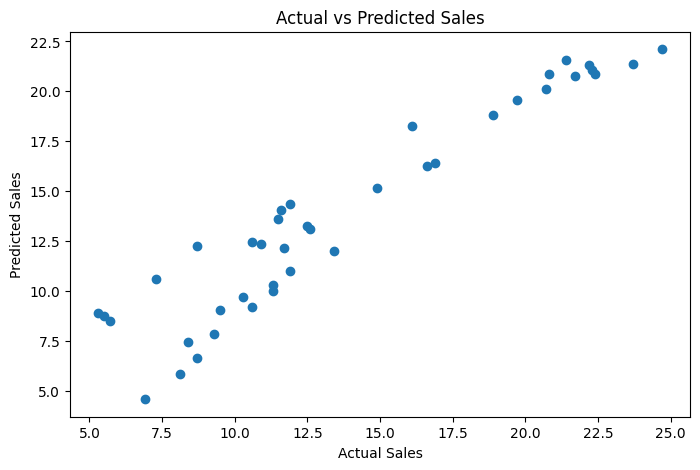

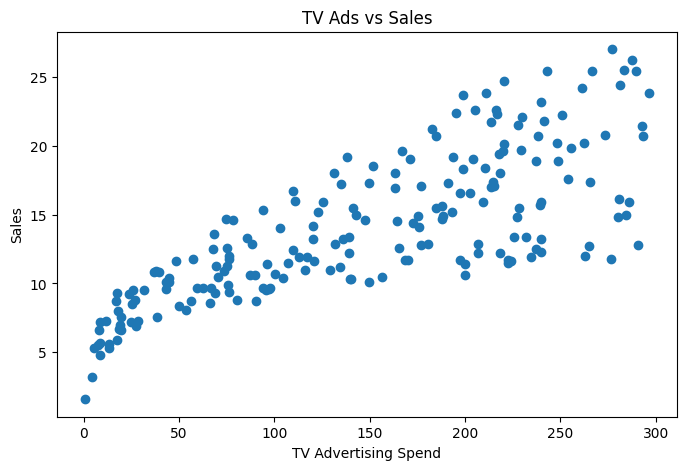

Predicted Future Sales: 20.613971470156297
Feature Impact:
TV: 0.044729517468716326
Radio: 0.18919505423437652
Newspaper: 0.0027611143413671935


C:\Users\shiva\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



Data = pd.read_csv("C:\\Users\\shiva\\Downloads\\archive (5)\\Advertising.csv")

# Show top rows
print(Data.head())


print(Data.info())
print(Data.isnull().sum())


Data.drop_duplicates(inplace=True)


X = Data[['TV', 'Radio', 'Newspaper']]
y = Data['Sales']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


prediction = model.predict(X_test)


print("MAE :", mean_absolute_error(y_test, prediction))
print("MSE :", mean_squared_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score:", r2_score(y_test, prediction))


plt.figure(figsize=(8,5))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(Data['TV'], Data['Sales'])
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Ads vs Sales")
plt.show()


#  Future Sales Prediction Example

# Input = TV, Radio, Newspaper spending

sample = [[230.1, 37.8, 69.2]]

future_sales = model.predict(sample)

print("Predicted Future Sales:", future_sales[0])


print("Feature Impact:")
print("TV:", model.coef_[0])
print("Radio:", model.coef_[1])
print("Newspaper:", model.coef_[2])